In [1]:
# import libraries
import numpy as np
import pickle
import pydtmc
import matplotlib.pyplot as plt

In [43]:
def categorize_diffusers(coordinates):
    """Recieves a coordinates array of shape [n_diffusers, 3], and returns an array of shape [n_diffusers],
    Where each entry is in the range [0,9] (inclusive). Which signify the following state states:
    0: Cytoplasm
    1-8: NPC radial segmets
    9: Nucleus
    """
    n_diffusers = coordinates.shape[0]
    categorized_coordinates = np.zeros(shape=(n_diffusers))
    
    # Create masks
    cyto_mask = coordinates[:, 2] >= 15
    nuc_mask = coordinates[:, 2] <= -15
    
    # apply masks
    angle = np.arctan2(coordinates[:, 1], coordinates[:, 0]) + np.pi
    eighth = np.floor(angle / (np.pi * 0.25)) + 1
    eighth[eighth == 9] = 8
    categorized_coordinates[((~cyto_mask) & (~nuc_mask))] = eighth[((~cyto_mask) & (~nuc_mask))]
    categorized_coordinates[cyto_mask] = 0
    categorized_coordinates[nuc_mask] = 9
    
    return categorized_coordinates


def categorize_diffusers2(coordinates):
    """Recieves a coordinates array of shape [n_diffusers, 3], and returns an array of shape [n_diffusers],
    Where each entry is in the range [0,9] (inclusive). Which signify the following state states:
    0: Cytoplasm
    1-8: NPC radial segmets (cytoplasm half)
    9-16: NPC radial segmets (nucleus half)
    17: Nucleus
    """
    n_diffusers = coordinates.shape[0]
    categorized_coordinates = np.zeros(shape=(n_diffusers))
    
    # Create masks
    cyto_mask = coordinates[:, 2] >= 15
    nuc_mask = coordinates[:, 2] <= -15
    cyto_half_mask = coordinates[:, 2] >= 0
    
    # apply masks
    angle = np.arctan2(coordinates[:, 1], coordinates[:, 0]) + np.pi
    eighth = np.floor(angle / (np.pi * 0.25)) + 1
    eighth[eighth == 9] = 8
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & cyto_half_mask)] = eighth[((~cyto_mask) & (~nuc_mask) & cyto_half_mask)]
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & (~cyto_half_mask))] = eighth[((~cyto_mask) & (~nuc_mask) & (~cyto_half_mask))] + 8
    categorized_coordinates[cyto_mask] = 0
    categorized_coordinates[nuc_mask] = 17
    
    return categorized_coordinates
    

In [44]:
with open("spatial_markov_chain_data.pickle", "rb") as f:
    trajectories = pickle.load(f)

n_diffusers = trajectories.shape[0]
n_t = trajectories.shape[2]
categorized_trajectories = np.zeros(shape=(n_diffusers, n_t))
categorized_trajectories2 = np.zeros(shape=(n_diffusers, n_t))
for t in range(n_t):
    categorized_trajectories[:,t] = categorize_diffusers(trajectories[:, :, t])
    categorized_trajectories2[:,t] = categorize_diffusers2(trajectories[:, :, t])

In [4]:
# Sanity check: Which NTRs fully passed through the NPC?
for i in range(250):
    if 0 in categorized_trajectories[i, :] and 9 in categorized_trajectories[i, :]:
        print(i)

3
4
68


In [38]:
def calc_transition_matrix(categorized_trajectories, n_states):
    transition_matrix = np.zeros(shape=(n_states,n_states))
    n_diffusers = categorized_trajectories.shape[0]
    n_t = categorized_trajectories.shape[1]
    
    for i in range(n_diffusers):
        for t in range(n_t - 1):
            first = int(categorized_trajectories[i,t])
            second = int(categorized_trajectories[i,t+1])
            transition_matrix[first, second] += 1
    for i in range(n_states):
        row_sum = np.sum(transition_matrix[i, :])
        if row_sum == 0:
            print(f"Row sum is 0, setting row {i} to 0    :( ")
            transition_matrix[i, :] = 0
            continue
        transition_matrix[i, :] = transition_matrix[i, :] / row_sum
    return transition_matrix

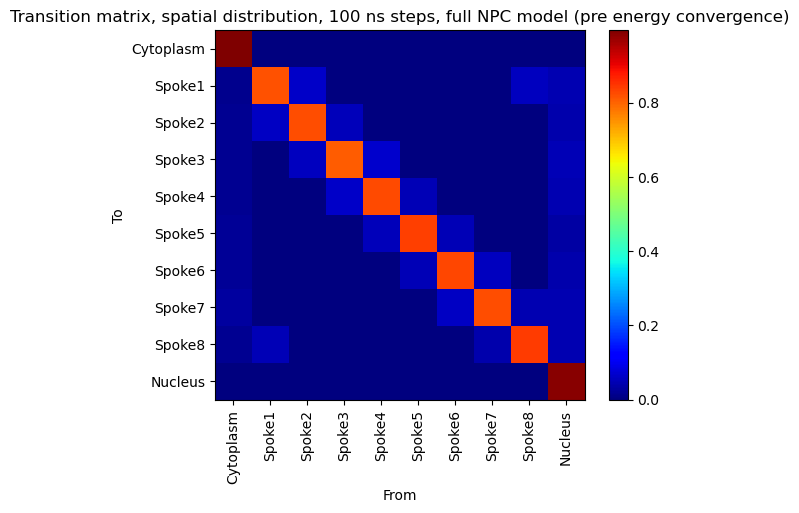

In [ ]:
transition_matrix = calc_transition_matrix(categorized_trajectories, 10)
# mc = pydtmc.MarkovChain(transition_matrix)
# pydtmc.plot_graph(mc)

plt.imshow(transition_matrix, cmap='jet', interpolation='nearest')
plt.xlabel("From")
plt.ylabel("To")
# Set ticks
plt.xticks(range(10), ["Cytoplasm", "Spoke1", "Spoke2", "Spoke3","Spoke4","Spoke5","Spoke6","Spoke7","Spoke8", "Nucleus"], rotation="vertical")
plt.yticks(range(10), ["Cytoplasm", "Spoke1", "Spoke2", "Spoke3","Spoke4","Spoke5","Spoke6","Spoke7","Spoke8", "Nucleus"])

plt.title("Transition matrix, spatial distribution, 100 ns steps, full NPC model (pre energy convergence)")
plt.colorbar()
plt.show()

/tmp/ipykernel_807557/3958547552.py:5: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(transition_matrix2), cmap='jet', interpolation='nearest')


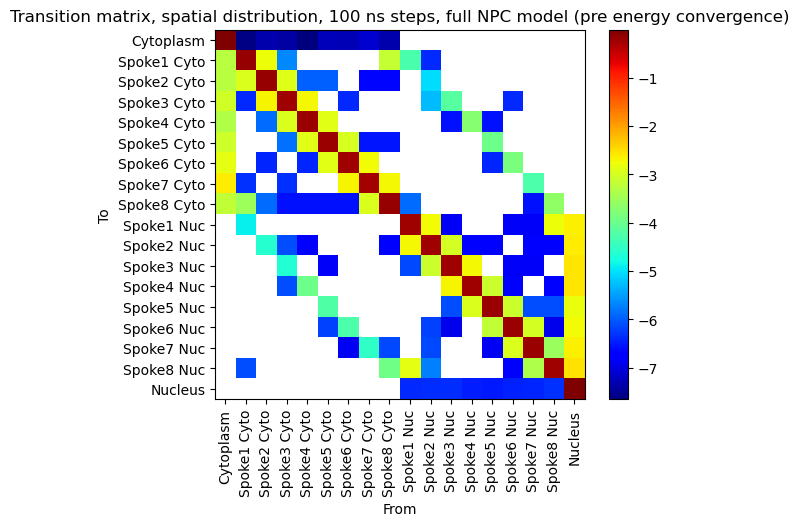

In [49]:
transition_matrix2 = calc_transition_matrix(categorized_trajectories2, 18)
# mc = pydtmc.MarkovChain(transition_matrix)
# pydtmc.plot_graph(mc)

plt.imshow(np.log(transition_matrix2), cmap='jet', interpolation='nearest')
plt.xlabel("From")
plt.ylabel("To")
# Set ticks
plt.xticks(range(18), ["Cytoplasm", "Spoke1 Cyto", "Spoke2 Cyto", "Spoke3 Cyto","Spoke4 Cyto","Spoke5 Cyto","Spoke6 Cyto","Spoke7 Cyto","Spoke8 Cyto", "Spoke1 Nuc", "Spoke2 Nuc", "Spoke3 Nuc","Spoke4 Nuc","Spoke5 Nuc","Spoke6 Nuc","Spoke7 Nuc","Spoke8 Nuc", "Nucleus"], rotation="vertical")
plt.yticks(range(18), ["Cytoplasm", "Spoke1 Cyto", "Spoke2 Cyto", "Spoke3 Cyto","Spoke4 Cyto","Spoke5 Cyto","Spoke6 Cyto","Spoke7 Cyto","Spoke8 Cyto", "Spoke1 Nuc", "Spoke2 Nuc", "Spoke3 Nuc","Spoke4 Nuc","Spoke5 Nuc","Spoke6 Nuc","Spoke7 Nuc","Spoke8 Nuc", "Nucleus"])


plt.title("Transition matrix, spatial distribution, 100 ns steps, full NPC model (pre energy convergence)")
plt.colorbar()
plt.show()


In [76]:
mc = pydtmc.MarkovChain(transition_matrix2)
n_sims = 1000
reached_end_sims = 0
tot_uniques = 0 
for i in range(n_sims):
    # start the sim at different spoke each time
    sim = mc.simulate(steps = 1000,
                initial_state=1 + i % 8, 
                output_indices=True)
    sim = np.array(sim)
    
    # Ignore all sims which did not reach nucleus
    indexes = np.where(sim == 17)
    if len(indexes[0]) == 0:
        continue

    # Ignore all sims which exited back to cytoplasm
    sim = sim[:indexes[0][0]]
    if len(np.where(sim == 0)[0]) != 0:
        continue
    
    uniques = len(np.unique(sim))
    reached_end_sims += 1
    tot_uniques += uniques
    
print(tot_uniques / reached_end_sims)

4.258687258687258
